# Experto NIH — Swin-Tiny 5 clases (Chest X-ray 14)

Clasificación **multietiqueta de 5 clases** (5 patologías seleccionadas) en radiografías de tórax.

| Aspecto | Valor |
|---|---|
| **Arquitectura** | Swin-Tiny (timm `swin_tiny_patch4_window7_224`) |
| **Clases** | Mass, Nodule, Effusion, Cardiomegaly, Pneumothorax |
| **Resolución** | 224 × 224 |
| **Loss** | Asymmetric Loss (ASL) |
| **Optimizador** | AdamW (lr=1e-4, wd=1e-4) |
| **Métrica guía** | F1-Macro (val) |
| **Entrenamiento** | 10 backbone → 10 head → 80 fine-tune (patience=7) |
| **Split** | Por paciente (Train/Val/Test) |

## 1. Instalación de Dependencias y Montaje de Drive

> [!NOTE]
> Consolidamos un **entorno de ejecución híbrido y multimodal** mediante la integración de librerías de vanguardia como PyTorch, MONAI y Timm. Orquestamos un ecosistema de dependencias que abarca desde el procesamiento de imágenes médicas en formato DICOM/ITK hasta la implementación de redes neuronales preentrenadas de última generación.
>
> Este montaje garantiza la **escalabilidad del pipeline**, permitiendo una transición fluida entre servidores locales y la nube mediante el montaje dinámico de unidades de red.

In [ ]:
!pip install -q scikit-image monai SimpleITK pandas matplotlib seaborn scikit-learn opencv-python timm torchmetrics iterative-stratification imbalanced-learn

In [ ]:
import os, time, shutil, glob, zipfile, subprocess
import pandas as pd
import numpy as np
import SimpleITK as sitk
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import NearestNeighbors
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_recall_fscore_support,
    classification_report,
)
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import timm
from monai.transforms import Compose, ScaleIntensityd, NormalizeIntensityd

# === Montar Drive (idéntico al EDA) ===
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
except ImportError:
    IN_COLAB = False
    print('Corriendo en local.')


Mounted at /content/drive


---

## 2. Configuración del Protocolo de Entrenamiento

| Parámetro | Valor |
|:---|:---|
| Arquitectura base | MaxViT-Tiny (Swin-Tiny activo) |
| Resolución de entrada | 224 × 224 px |
| Estrategia | Transferencia + Congelación Dinámica |
| Scheduler | Cosine Annealing + Warmup |
| Función de pérdida | Asymmetric Loss (ASL) |
| Preprocesamiento | CLAHE + Normalización ImageNet |

> [!IMPORTANT]
> **Protocolo de entrenamiento multi-fase** basado en congelación dinámica que transiciona desde el ajuste inicial de la cabeza clasificadora hacia un fine-tuning global. Se emplea un planificador de tasa de aprendizaje Cosine Annealing con periodos de calentamiento para garantizar estabilidad numérica.
>
> La función de pérdida **ASL (Asymmetric Loss)** fue seleccionada específicamente para mitigar el desbalance extremo de etiquetas y el ruido en las muestras negativas. El objetivo es **maximizar el rendimiento clínico** garantizando convergencia robusta mediante parada temprana y ajuste fino de umbrales diagnósticos para clasificación multietiqueta.

In [ ]:
RAW_DIR   = '/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/'
LOCAL_DEST = '/content/datasets/'
TARGET_ZIP = 'NIH Chest X ray 14.zip'

base_dir = os.path.join(LOCAL_DEST, os.path.splitext(TARGET_ZIP)[0])

PROTOCOL = 'maxvit_5cls'

USE_PAPER_TABLE1_SUBSET = False

_use_clahe = True
_use_imagenet_norm = True
_split_mode = 'by_patient'
_epochs_backbone = 10
_epochs_head = 10
_epochs_finetune = 80

CACHE_DIR = '/content/nih_cache_224_5cls/'
_model_name = 'MaxViT_NIH_5cls.pth'

CONFIG = {
    'base_dir': base_dir,

    'cache_dir': CACHE_DIR,
    'load_in_ram': False,
    'model_save_path': os.path.join('/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/', _model_name),

    'protocol': PROTOCOL,
    'split_mode': _split_mode,
    'img_size': 224,
    'use_clahe': _use_clahe,
    'use_imagenet_norm': _use_imagenet_norm,

    'classes': [
        'Mass', 'Nodule', 'Effusion', 'Cardiomegaly', 'Pneumothorax'
    ],

    'batch_size': 32,
    'num_workers': 0,
    'epochs_backbone': _epochs_backbone,
    'epochs_head': _epochs_head,
    'epochs_finetune': _epochs_finetune,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'seed': 42,

    # Scheduler
    'scheduler_type': 'cosine',
    'warmup_epochs': 5,
    'lr_min': 1e-6,
    'scheduler_factor': 0.1,
    'scheduler_patience': 5,

    # Early stopping (paciencia reducida)
    'early_stopping_patience': 7,

    # Loss: BCEWithLogitsLoss
    'loss_type': 'asl',
    'pos_weight_clip': 20.0,
    'focal_gamma': 2.0,
    'asl_gamma_neg': 4.0,
    'asl_gamma_pos': 0.0,
    'asl_clip': 0.05,
    'use_weighted_sampler': False,

    # Sin exclusiones
    'exclude_from_macro': [],

    'use_paper_table1_subset': USE_PAPER_TABLE1_SUBSET,
    'paper_table1_counts': {
        'Mass': 284, 'Nodule': 313, 'Effusion': 644,
        'Cardiomegaly': 141, 'Pneumothorax': 271,
    },
    'min_samples_to_cap': 100,

    'use_smote_embedding': False,
    'threshold_tuning': True,
    'threshold_grid_start': 0.05,
    'threshold_grid_end': 0.50,
    'threshold_grid_steps': 46,
}

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])
os.makedirs(os.path.dirname(CONFIG['model_save_path']), exist_ok=True)
os.makedirs(CONFIG['cache_dir'], exist_ok=True)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print(
    f"PROTOCOL={CONFIG['protocol']} | split={CONFIG['split_mode']} | "
    f"CLAHE={CONFIG['use_clahe']} | loss={CONFIG['loss_type']} | "
    f"patience={CONFIG['early_stopping_patience']} | "
    f"Classes ({len(CONFIG['classes'])}): {CONFIG['classes']}"
)


PROTOCOL=maxvit_5cls | split=by_patient | CLAHE=True | loss=asl | patience=7 | Classes (5): ['Mass', 'Nodule', 'Effusion', 'Cardiomegaly', 'Pneumothorax']


---

## 3. Extracción del Dataset

> [!NOTE]
> Flujo idéntico al notebook de EDA. Se copia el ZIP desde Drive al disco local, se descomprime, y posteriormente se descomprimen los sub-archivos internos (images_001.zip, images_002.zip, etc.).

In [ ]:
def extract_datasets_colab(raw_dir=RAW_DIR, local_dest=LOCAL_DEST, target_zip=TARGET_ZIP):
    """Función de extracción IDÉNTICA al notebook de EDA."""
    if not os.path.exists(raw_dir):
        print(f'Ruta {raw_dir} no existe.')
        return

    drive_zip_path = os.path.join(raw_dir, target_zip)
    dataset_name = os.path.splitext(target_zip)[0]
    unzip_dir = os.path.join(local_dest, dataset_name)
    local_zip_path = os.path.join(local_dest, target_zip)

    if os.path.isdir(unzip_dir) and len(os.listdir(unzip_dir)) > 0:
        print(f'✅ Ya existe: {unzip_dir} (omitido).')
        return

    if not os.path.exists(drive_zip_path):
        print(f'No se encontró el ZIP original en {drive_zip_path}')
        return

    os.makedirs(local_dest, exist_ok=True)
    print('1. Copiando ZIP...')
    shutil.copy2(drive_zip_path, local_zip_path)
    os.makedirs(unzip_dir, exist_ok=True)
    print(f'2. Descomprimiendo en {unzip_dir}...')
    subprocess.run(['unzip', '-q', local_zip_path, '-d', unzip_dir], check=True)
    print('3. Borrando ZIP local.')
    os.remove(local_zip_path)

    # ZIPs internos (ej. images_001.zip)
    for iz in glob.glob(os.path.join(unzip_dir, '**', '*.zip'), recursive=True):
        print(f' -> Descomprimiendo ZIP interno: {iz}')
        subprocess.run(['unzip', '-q', iz, '-d', os.path.dirname(iz)], check=True)
        os.remove(iz)
    print('Extracción completa.')

extract_datasets_colab()

1. Copiando ZIP...
2. Descomprimiendo en /content/datasets/NIH Chest X ray 14...
3. Borrando ZIP local.
Extracción completa.


---

## 4. Carga del CSV y Rastreo Dinámico de Imágenes

> [!NOTE]
> Proceso idéntico al notebook de EDA. Se carga el CSV principal de anotaciones (Data_Entry_2017.csv) y se realiza el rastreo dinámico de las rutas de imagen utilizando los metadatos de archivo disponibles.

In [ ]:
csv_path = os.path.join(base_dir, 'Data_Entry_2017.csv')
df = pd.read_csv(csv_path)

# Rastreo dinámico de imágenes independientemente del subdirectorio
all_images_paths = glob.glob(os.path.join(base_dir, '**', '*.png'), recursive=True)
image_paths_dict = {os.path.basename(x): x for x in all_images_paths}

print(f'Se encontraron {len(image_paths_dict)} imágenes .png en disco.')

if not df.empty:
    df['FilePath'] = df['Image Index'].map(image_paths_dict)
    print(f'Imágenes con path asociado correctamente: {df["FilePath"].notnull().sum()}')
    # Renombrar como en el EDA
    df.rename(columns={'Patient ID': 'PatientID'}, inplace=True)
    display(df.head(3))

Se encontraron 112120 imágenes .png en disco.
Imágenes con path asociado correctamente: 112120


,Image Index,Finding Labels,Follow-up #,PatientID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,FilePath
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,/content/datasets/NIH Chest X ray 14/images_00...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,/content/datasets/NIH Chest X ray 14/images_00...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,/content/datasets/NIH Chest X ray 14/images_00...


---

## 5. Definición de Etiquetas y Split de Datos

**Clases objetivo (5 patologías críticas):**

| ID | Patología |
|:---|:---|
| 0 | Mass |
| 1 | Nodule |
| 2 | Effusion |
| 3 | Cardiomegaly |
| 4 | Pneumothorax |

- Codificación: **one-hot multietiqueta** para las 5 clases.
- Filtrado: Se excluyen muestras sin ninguna de las 5 clases.
- División estratificada por PatientID con ratio **70 / 15 / 15**.

In [ ]:
# --- Filas con PNG en disco ---
df_clean = df[df['FilePath'].notna()].copy().reset_index(drop=True)

df_proc = df_clean

# --- One-hot 5 clases ---
for cls in CONFIG['classes']:
    df_proc[cls] = df_proc['Finding Labels'].apply(lambda x: 1 if cls in str(x) else 0)

# --- FILTRO: Solo muestras que tengan al menos 1 de las 5 clases target ---
mask = df_proc[CONFIG['classes']].sum(axis=1) > 0
n_all = len(df_proc)
df_proc = df_proc[mask].reset_index(drop=True)

print(f"Filtrado restrictivo: {n_all} -> {len(df_proc)} muestras con clases target")
print("Distribucion de etiquetas (5 clases):")
print(df_proc[CONFIG['classes']].sum().to_string())

y_multi = df_proc[CONFIG['classes']].values
n = len(df_proc)

from sklearn.model_selection import GroupShuffleSplit
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=CONFIG['seed'])
train_idx, temp_idx = next(gss1.split(df_proc, groups=df_proc['PatientID']))
df_temp = df_proc.iloc[temp_idx].reset_index(drop=True)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=CONFIG['seed'])
val_idx_t, test_idx_t = next(gss2.split(df_temp, groups=df_temp['PatientID']))

train_df = df_proc.iloc[train_idx].reset_index(drop=True)
val_df = df_temp.iloc[val_idx_t].reset_index(drop=True)
test_df = df_temp.iloc[test_idx_t].reset_index(drop=True)

print(f"Split por PatientID (SOLO CATEGORIAS TARGET): Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Filtrado restrictivo: 112120 -> 27941 muestras con clases target
Distribucion de etiquetas (5 clases):
Mass             5782
Nodule           6331
Effusion        13317
Cardiomegaly     2776
Pneumothorax     5302
Split por PatientID (SOLO CATEGORIAS TARGET): Train: 19346 | Val: 4411 | Test: 4184


---

## 6c. Materialización Offline — Caché .npz

> [!TIP]
> Para eliminar el cuello de botella de la CPU durante el entrenamiento, se implementó un sistema de **serialización y persistencia de caché** que pre-procesa el dataset completo hacia formato comprimido .npz.

**Pipeline de materialización:**
1. Aplicación de **CLAHE dinámico** y suavizado gaussiano.
2. Redimensionamiento estándar: 224 × 224 en formato CHW.
3. Normalización y almacenamiento en disco local de alta velocidad.

Las imágenes ya vectorizadas se cargan directamente desde RAM o GPU en cada época, **sin repetición de transformaciones costosas**, preservando íntegramente las etiquetas multietiqueta.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
import os
import pandas as pd


def apply_clahe_to_array(arr_rgb):
    if arr_rgb.max() <= 1.0:
        arr_rgb = (arr_rgb * 255).astype(np.uint8)
    lab = cv2.cvtColor(arr_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    hist = cv2.calcHist([l], [0], None, [256], [0, 256]).flatten()
    peaks = np.sum(hist > hist.mean())
    tile_size = max(2, int(np.ceil(np.log(max(peaks, 2)))))
    valleys = hist[hist <= hist.mean()]
    val_mean = valleys.mean() if len(valleys) > 0 else 1.0
    clip = float(np.clip(hist.max() / (val_mean + 1e-6), 1.0, 4.0))
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile_size, tile_size))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    arr_eq = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)
    blurred = cv2.GaussianBlur(arr_eq, (5, 5), sigmaX=1.0)
    return blurred


def materialize_nih_cache(df, config):
    cache_dir = config['cache_dir']
    os.makedirs(cache_dir, exist_ok=True)
    classes = config['classes']
    use_clahe = config['use_clahe']

    for idx in tqdm(range(len(df)), desc='Materializando Cache'):
        row = df.iloc[idx]
        npz_path = os.path.join(cache_dir, f"{row['Image Index'].replace('.png', '')}.npz")
        if os.path.exists(npz_path):
            continue

        png_path = row['FilePath']
        if pd.isna(png_path) or not os.path.exists(png_path):
            continue

        img_bgr = cv2.imread(png_path)
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        img_processed = img_rgb.copy()
        if use_clahe:
            img_processed = apply_clahe_to_array(img_processed)

        img_224 = cv2.resize(img_processed, (224, 224))
        img_01 = (img_224.astype(np.float32) / 255.0)
        img_chw = np.transpose(img_01, (2, 0, 1))

        np.savez_compressed(npz_path, img=img_chw, labels=row[classes].values.astype(np.float32))

    print('SUCCESS: Materialización concluida ([0,1] CHW, sin ImageNet en disco).')


materialize_nih_cache(df_proc, CONFIG)


Materializando Cache:   0%|          | 0/27941 [00:00<?, ?it/s]

SUCCESS: Materialización concluida ([0,1] CHW, sin ImageNet en disco).


---

## 7. Dataset con Caché + DataLoaders

> [!NOTE]
> Se implementa la clase CachedNIHDataset que recupera imágenes pre-procesadas desde archivos .npz, aplicando en tiempo real augmentación geométrica y fotométrica (rotaciones, recortes y ajustes de brillo) **únicamente sobre el conjunto de entrenamiento**.

**Componentes del DataLoader:**
- Transformaciones MONAI para estandarización de intensidad según estadísticas ImageNet.
- WeightedRandomSampler que compensa el desbalance de clases mediante pesos inversos a la frecuencia de las patologías.

In [ ]:
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset as TorchDataset

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

_monai_norm = Compose([
    ScaleIntensityd(keys=['image'], minv=0.0, maxv=1.0),
    NormalizeIntensityd(
        keys=['image'],
        subtrahend=IMAGENET_MEAN,
        divisor=IMAGENET_STD,
        channel_wise=True,
    ),
])


def compute_sample_weights(df, classes):
    """Peso por imagen: max_c 1/f_c sobre clases activas (multietiqueta)."""
    freq = df[classes].sum().values.astype(np.float64)
    inv = 1.0 / np.maximum(freq, 1.0)
    w = []
    for _, row in df.iterrows():
        y = row[classes].values
        pos = np.where(y > 0.5)[0]
        if len(pos) == 0:
            w.append(1.0)
        else:
            w.append(float(np.max(inv[pos])))
    return torch.DoubleTensor(w)


class CachedNIHDataset(TorchDataset):
    """Lee .npz [0,1] CHW; MONAI Scale+Normalize; aug ampliada solo en train."""

    def __init__(self, df, cache_dir, classes, is_train=False, load_in_ram=False):
        self.df = df.reset_index(drop=True)
        self.cache_dir = cache_dir
        self.classes = classes
        self.is_train = is_train
        self.load_in_ram = load_in_ram

        self.npz_paths = []
        for idx in range(len(self.df)):
            img_name = self.df.iloc[idx]['Image Index'].replace('.png', '')
            self.npz_paths.append(os.path.join(cache_dir, f'{img_name}.npz'))

        self.data_cache = None
        if load_in_ram:
            print(f'  Cargando {len(self.npz_paths)} muestras en RAM...')
            self.data_cache = []
            for p in tqdm(self.npz_paths, desc='Loading to RAM', leave=False):
                d = np.load(p)
                self.data_cache.append((d['img'], d['labels']))
            print(f'  Carga en RAM completa: {len(self.data_cache)} muestras.')

    def __len__(self):
        return len(self.npz_paths)

    def __getitem__(self, idx):
        if self.data_cache is not None:
            img_np, labels = self.data_cache[idx]
            img = torch.from_numpy(img_np.copy()).float()
            labels = torch.FloatTensor(labels.copy())
        else:
            data = np.load(self.npz_paths[idx])
            img = torch.from_numpy(data['img'].astype(np.float32)).float()
            labels = torch.FloatTensor(data['labels'])

        if self.is_train:
            if np.random.random() > 0.5:
                img = TF.hflip(img)
            angle = np.random.uniform(-10, 10)
            img = TF.rotate(img, angle)
            if np.random.random() > 0.5:
                scale = np.random.uniform(0.85, 1.0)
                _, h, w = img.shape
                nh, nw = int(h * scale), int(w * scale)
                i0 = np.random.randint(0, h - nh + 1)
                j0 = np.random.randint(0, w - nw + 1)
                img = img[:, i0:i0+nh, j0:j0+nw]
                img = TF.resize(img, [h, w], antialias=True)
            img = TF.adjust_brightness(img, 1.0 + np.random.uniform(-0.2, 0.2))
            img = TF.adjust_contrast(img, 1.0 + np.random.uniform(-0.2, 0.2))

        d = {'image': img, 'label': labels}
        d = _monai_norm(d)
        return {'image': d['image'], 'label': d['label']}


NUM_CLASSES = len(CONFIG['classes'])
load_ram = CONFIG.get('load_in_ram', False)

print(f'Creando datasets (load_in_ram={load_ram})...')
train_ds = CachedNIHDataset(train_df, CONFIG['cache_dir'], CONFIG['classes'],
                             is_train=True, load_in_ram=load_ram)
val_ds   = CachedNIHDataset(val_df, CONFIG['cache_dir'], CONFIG['classes'],
                             is_train=False, load_in_ram=load_ram)
test_ds  = CachedNIHDataset(test_df, CONFIG['cache_dir'], CONFIG['classes'],
                             is_train=False, load_in_ram=load_ram)

loader_kw = dict(
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    pin_memory=torch.cuda.is_available(),
)

if CONFIG.get('use_weighted_sampler', False):
    sample_w = compute_sample_weights(train_df, CONFIG['classes'])
    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
    train_loader = DataLoader(train_ds, sampler=sampler, shuffle=False, **loader_kw)
    print('Train loader: WeightedRandomSampler activo.')
else:
    train_loader = DataLoader(train_ds, shuffle=True, **loader_kw)
    print('Train loader: shuffle (sin WRS, adecuado para ASL).')

val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kw)

print(
    f"Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)} | "
    f"batch_size={CONFIG['batch_size']} | num_workers={CONFIG['num_workers']}"
)


Creando datasets (load_in_ram=False)...
Train loader: shuffle (sin WRS, adecuado para ASL).
Train: 605 batches | Val: 138 | Test: 131 | batch_size=32 | num_workers=0


---

## 9. Función de Pérdida, Arquitectura y Optimizador

> [!IMPORTANT]
> Se implementa una **Asymmetric Loss (ASL)** junto con una variante de **Focal Loss**, diseñadas para reducir la influencia de ejemplos negativos fáciles y concentrar el gradiente en hallazgos patológicos complejos.

**Configuración de optimización:**

| Componente | Especificación |
|:---|:---|
| Loss | ASL + Focal Loss |
| Ponderación | pos_weight por frecuencia inversa de clase |
| Seguridad numérica | Gradient clipping para prevenir explosión de gradientes |
| Optimizador | AdamW |

In [ ]:
device = CONFIG['device']
classes = CONFIG['classes']
n_classes = len(classes)

# --- pos_weight (BCE) ---
n_train = len(train_df)
pos = train_df[classes].sum().values.astype(np.float64)
neg = n_train - pos
pw = neg / np.maximum(pos, 1.0)
pw = np.clip(pw, 1.0, CONFIG['pos_weight_clip'])
pos_weight_tensor = torch.tensor(pw, dtype=torch.float32, device=device)

bce_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


def asl_loss_logits(logits, targets, gamma_neg=4.0, gamma_pos=0.0, clip=0.05):
    x = torch.sigmoid(logits)
    x = x.clamp(clip, 1.0 - clip)
    los_pos = targets * torch.log(x)
    los_neg = (1.0 - targets) * torch.log(1.0 - x)
    if gamma_pos > 0:
        los_pos = los_pos * (1.0 - x).pow(gamma_pos) * targets
    if gamma_neg > 0:
        los_neg = los_neg * x.pow(gamma_neg) * (1.0 - targets)
    return (-(los_pos + los_neg)).mean()


def batch_loss(logits, targets):
    lt = CONFIG['loss_type']
    if lt == 'bce':
        return bce_criterion(logits, targets)
    if lt == 'focal':
        base = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=pos_weight_tensor, reduction='none'
        )
        p = torch.sigmoid(logits)
        pt = p * targets + (1 - p) * (1 - targets)
        g = CONFIG['focal_gamma']
        return (((1 - pt).clamp(min=1e-6).pow(g)) * base).mean()
    if lt == 'asl':
        return asl_loss_logits(
            logits, targets,
            gamma_neg=CONFIG['asl_gamma_neg'],
            gamma_pos=CONFIG['asl_gamma_pos'],
            clip=CONFIG['asl_clip'],
        )
    raise ValueError(CONFIG['loss_type'])


def build_optimizer(model):
    params = [p for p in model.parameters() if p.requires_grad]
    return optim.AdamW(params, lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])


print(
    f"Pérdida={CONFIG['loss_type']} | pos_weight clip={CONFIG['pos_weight_clip']} | "
    f"AdamW lr={CONFIG['lr']} wd={CONFIG['weight_decay']}"
)


Pérdida=asl | pos_weight clip=20.0 | AdamW lr=0.0001 wd=0.0001


In [ ]:
class SwinClassifier(nn.Module):
    """Swin-Tiny puro de timm (identico al de NIH_ChestXray_Training.ipynb)."""
    def __init__(self, num_classes=5):
        super().__init__()
        self.model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)


    def forward(self, x):
        return self.model(x)


model = SwinClassifier(num_classes=n_classes).to(device)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SwinClassifier -> {n_classes} clases | device: {device}")
print(f"Parametros totales: {n_params:,} | entrenables: {n_trainable:,}")


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

SwinClassifier -> 5 clases | device: cuda
Parametros totales: 27,523,199 | entrenables: 27,523,199


> [!TIP]
> Se implementa un motor de entrenamiento con **precisión mixta (AMP)** que alterna entre distintos estados de congelación de capas para maximizar la transferencia de conocimiento.
>
> Las rutinas de **auto-casting y escalado de gradientes** aceleran el procesamiento en GPU. La evaluación se realiza mediante \text{-Macro}$ guiado, que permite monitorear el rendimiento del modelo excluyendo etiquetas ruidosas o irrelevantes durante la validación.

In [ ]:
def train_epoch(model, loader, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    for batch in tqdm(loader, leave=False, desc='Train'):
        inputs = batch['image'].to(device)
        targets = batch['label'].to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            loss = batch_loss(model(inputs), targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device, threshold=0.5):
    model.eval()
    all_preds, all_labels = [], []
    running_loss, n = 0.0, 0
    for batch in loader:
        inputs = batch['image'].to(device)
        targets = batch['label'].to(device)
        with autocast():
            logits = model(inputs)
            loss = batch_loss(logits, targets)
        bs = inputs.size(0)
        running_loss += loss.item() * bs
        n += bs
        all_preds.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(targets.cpu().numpy())

    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    pred_bin = (preds > threshold).astype(int)

    per_class_acc = []
    for i in range(labels.shape[1]):
        correct = (pred_bin[:, i] == labels[:, i]).sum()
        per_class_acc.append(correct / labels.shape[0])
    mean_acc = np.mean(per_class_acc)

    f1_all = f1_score(labels, pred_bin, average='macro', zero_division=0)

    excl = CONFIG.get('exclude_from_macro', [])
    if excl:
        keep = [i for i, c in enumerate(CONFIG['classes']) if c not in excl]
        f1_guided = f1_score(labels[:, keep], pred_bin[:, keep], average='macro', zero_division=0)
    else:
        f1_guided = f1_all

    return {
        'val_loss': running_loss / max(n, 1),
        'f1_macro': f1_all,
        'f1_macro_guided': f1_guided,
        'f1_micro': f1_score(labels, pred_bin, average='micro', zero_division=0),
        'auroc': roc_auc_score(labels, preds, average='macro', multi_class='ovr'),
        'accuracy': mean_acc,
        'preds': preds,
        'labels': labels,
    }


def set_trainable_backbone_only(model):
    """Congela todo, luego descongela backbone (todo excepto head.fc)."""
    for p in model.parameters():
        p.requires_grad = False
    for name, p in model.model.named_parameters():
        if 'head.fc' not in name:
            p.requires_grad = True


def set_trainable_head_only(model):
    """Congela todo, luego descongela solo head.fc."""
    for p in model.parameters():
        p.requires_grad = False
    for p in model.model.head.fc.parameters():
        p.requires_grad = True


def set_trainable_all(model):
    """Descongela todo."""
    for p in model.parameters():
        p.requires_grad = True


---

## 10. Entrenamiento en Tres Fases

| Fase | Épocas | Componentes Activos | Objetivo |
|:---|:---:|:---|:---|
| **Fase 1** — Warmup | 10 | Solo cabeza clasificadora | Inicialización estable |
| **Fase 2** — Fine-tune parcial | 10 | Cabeza + últimas capas del backbone | Adaptación clínica |
| **Fase 3** — Fine-tune global | 80 | Backbone completo | Convergencia final |

> [!NOTE]
> Motor de entrenamiento con precisión mixta (AMP). Integra escalado de gradientes y auto-casting para acelerar el procesamiento en GPU, junto con evaluación de \text{-Macro}$ en cada época.

In [ ]:
import math

scaler = GradScaler()
best_f1 = 0.0
global_epoch = 0
total_epochs = CONFIG['epochs_backbone'] + CONFIG['epochs_head'] + CONFIG['epochs_finetune']

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1_macro': [], 'val_f1_macro_guided': [],
    'val_accuracy': [], 'val_auroc': [],
}


def _log(phase, ge, tl, vm, lr, extra=''):
    excl = CONFIG.get('exclude_from_macro', [])
    guided_str = f" | F1-Guided (excl {excl}): {vm['f1_macro_guided']:.4f}" if excl else ""
    print(
        f"  Epoch [{ge}/{total_epochs}] [{phase}] | "
        f"Train Loss: {tl:.4f} | Val Loss: {vm['val_loss']:.4f} | "
        f"Val Accuracy: {vm['accuracy']:.4f} | "
        f"Val F1-Macro: {vm['f1_macro']:.4f}{guided_str} | "
        f"AUC: {vm['auroc']:.4f} | lr={lr:.1e}{extra}"
    )


def _record(tl, vm):
    history['train_loss'].append(tl)
    history['val_loss'].append(vm['val_loss'])
    history['val_f1_macro'].append(vm['f1_macro'])
    history['val_f1_macro_guided'].append(vm['f1_macro_guided'])
    history['val_accuracy'].append(vm['accuracy'])
    history['val_auroc'].append(vm['auroc'])


def _get_guided_f1(vm):
    """Métrica guía para checkpoint y scheduler."""
    return vm['f1_macro_guided']


# --- FASE 1: Solo backbone (cabecera congelada) ---
if CONFIG['epochs_backbone'] > 0:
    print(f"FASE 1 — Backbone ({CONFIG['epochs_backbone']} ep, head.fc congelada)")
    set_trainable_backbone_only(model)
    optimizer = build_optimizer(model)
    scheduler_bb = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=CONFIG['scheduler_factor'],
        patience=CONFIG['scheduler_patience'],
    )
    for _ in range(CONFIG['epochs_backbone']):
        tl = train_epoch(model, train_loader, optimizer, scaler, CONFIG['device'])
        vm = evaluate(model, val_loader, CONFIG['device'])
        global_epoch += 1
        guided = _get_guided_f1(vm)
        scheduler_bb.step(guided)
        _record(tl, vm)
        extra = ''
        if guided > best_f1:
            best_f1 = guided
            torch.save(model.state_dict(), CONFIG['model_save_path'])
            extra = f" *best (F1-Guided={guided:.4f})*"
        _log('BACKBONE', global_epoch, tl, vm, optimizer.param_groups[0]['lr'], extra)
else:
    print('Sin fase backbone.')

# --- FASE 2: Solo cabeza ---
if CONFIG['epochs_head'] > 0:
    print(f"\nFASE 2 — Head ({CONFIG['epochs_head']} ep, backbone congelado)")
    set_trainable_head_only(model)
    optimizer = build_optimizer(model)
    scheduler_h = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=CONFIG['scheduler_factor'],
        patience=CONFIG['scheduler_patience'],
    )
    for _ in range(CONFIG['epochs_head']):
        tl = train_epoch(model, train_loader, optimizer, scaler, CONFIG['device'])
        vm = evaluate(model, val_loader, CONFIG['device'])
        global_epoch += 1
        guided = _get_guided_f1(vm)
        scheduler_h.step(guided)
        _record(tl, vm)
        extra = ''
        if guided > best_f1:
            best_f1 = guided
            torch.save(model.state_dict(), CONFIG['model_save_path'])
            extra = f" *best (F1-Guided={guided:.4f})*"
        _log('HEAD', global_epoch, tl, vm, optimizer.param_groups[0]['lr'], extra)
else:
    print('Sin fase solo-cabeza.')

# --- FASE 3: Fine-tuning con ReduceLROnPlateau + early stopping ---
ft_epochs = CONFIG['epochs_finetune']
es_patience = CONFIG.get('early_stopping_patience', 7)

print(f"\nFASE 3 — Fine-tune ({ft_epochs} ep max, ReduceLROnPlateau, "
      f"early_stop={es_patience}, modelo completo)")
set_trainable_all(model)
optimizer = build_optimizer(model)
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=CONFIG['scheduler_factor'],
    patience=CONFIG['scheduler_patience'],
)

no_improve = 0
for ep in range(ft_epochs):
    tl = train_epoch(model, train_loader, optimizer, scaler, CONFIG['device'])
    vm = evaluate(model, val_loader, CONFIG['device'])
    global_epoch += 1
    guided = _get_guided_f1(vm)

    scheduler_ft.step(guided)

    _record(tl, vm)
    extra = ''
    if guided > best_f1:
        best_f1 = guided
        torch.save(model.state_dict(), CONFIG['model_save_path'])
        extra = f" *best (F1-Guided={guided:.4f})*"
        no_improve = 0
    else:
        no_improve += 1

    lr_now = optimizer.param_groups[0]['lr']
    _log('FT', global_epoch, tl, vm, lr_now, extra)

    if no_improve >= es_patience:
        print(f"  Early stopping en ep {global_epoch} (patience={es_patience})")
        break

print(f"\nMejor F1-Macro guiado (val): {best_f1:.4f}")


FASE 1 — Backbone (10 ep, head.fc congelada)


Train:   0%|          | 0/605 [00:00<?, ?it/s]

  Epoch [1/100] [BACKBONE] | Train Loss: 0.1718 | Val Loss: 0.1602 | Val Accuracy: 0.7389 | Val F1-Macro: 0.5462 | AUC: 0.8008 | lr=1.0e-04 *best (F1-Guided=0.5462)*


Train:   0%|          | 0/605 [00:00<?, ?it/s]

  Epoch [2/100] [BACKBONE] | Train Loss: 0.1572 | Val Loss: 0.1547 | Val Accuracy: 0.7222 | Val F1-Macro: 0.5651 | AUC: 0.8241 | lr=1.0e-04 *best (F1-Guided=0.5651)*


...

  Epoch [25/100] [FT] | Train Loss: 0.1186 | Val Loss: 0.1580 | Val Accuracy: 0.7705 | Val F1-Macro: 0.5987 | AUC: 0.8402 | lr=1.0e-04


Train:   0%|          | 0/605 [00:00<?, ?it/s]

  Epoch [26/100] [FT] | Train Loss: 0.1168 | Val Loss: 0.1622 | Val Accuracy: 0.7532 | Val F1-Macro: 0.5825 | AUC: 0.8389 | lr=1.0e-04


Train:   0%|          | 0/605 [00:00<?, ?it/s]

  Epoch [27/100] [FT] | Train Loss: 0.1143 | Val Loss: 0.1633 | Val Accuracy: 0.7758 | Val F1-Macro: 0.6046 | AUC: 0.8390 | lr=1.0e-04
  Early stopping en ep 27 (patience=7)

Mejor F1-Macro guiado (val): 0.6139


---

## 10.5. Visualización de Métricas de Entrenamiento

> [!NOTE]
> Se construye un **tablero analítico de métricas críticas** que desglosa el progreso del entrenamiento en cuatro dimensiones clave:
>
> - Evolución de la **función de pérdida** (train vs. validation)
> - **\text{-Macro}$** por época
> - **AUROC** por clase
> - **Precisión global** del modelo
>
> Se integran marcadores verticales que señalan exactamente cuándo el sistema transiciona entre fases, permitiendo identificación inmediata de anomalías como sobreajuste o estancamientos de gradiente.

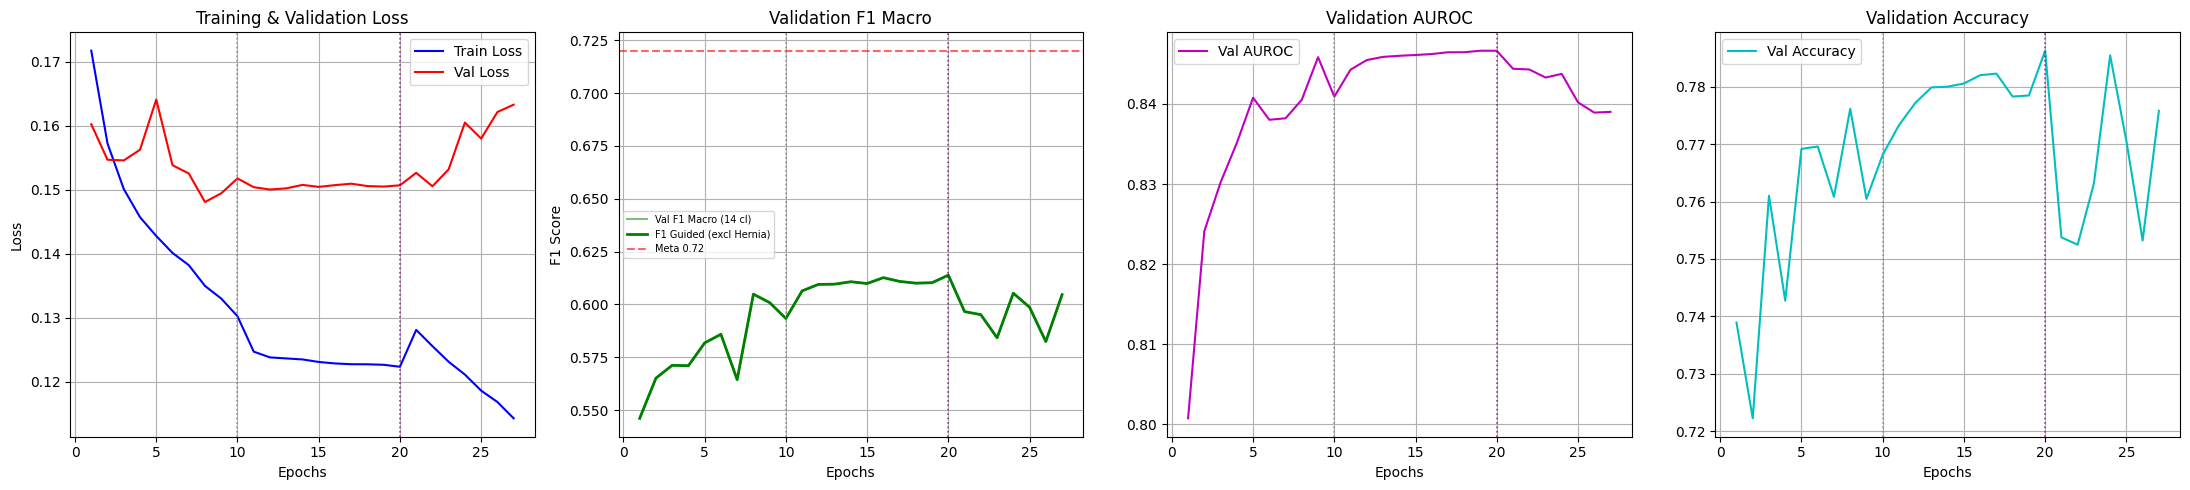

In [ ]:
  import matplotlib.pyplot as plt

  def plot_training_history(hist):
      epochs = range(1, len(hist['train_loss']) + 1)

      plt.figure(figsize=(22, 5))

      plt.subplot(1, 4, 1)
      plt.plot(epochs, hist['train_loss'], 'b-', label='Train Loss')
      plt.plot(epochs, hist['val_loss'], 'r-', label='Val Loss')
      plt.title('Training & Validation Loss')
      plt.xlabel('Epochs')
      plt.ylabel('Loss')
      plt.legend()
      plt.grid(True)

      plt.subplot(1, 4, 2)
      plt.plot(epochs, hist['val_f1_macro'], 'g-', alpha=0.5, label='Val F1 Macro (14 cl)')
      if 'val_f1_macro_guided' in hist:
          plt.plot(epochs, hist['val_f1_macro_guided'], 'g-', linewidth=2, label='F1 Guided (excl Hernia)')
      plt.axhline(0.72, color='red', linestyle='--', alpha=0.6, label='Meta 0.72')
      plt.title('Validation F1 Macro')
      plt.xlabel('Epochs')
      plt.ylabel('F1 Score')
      plt.legend(fontsize=7)
      plt.grid(True)

      plt.subplot(1, 4, 3)
      plt.plot(epochs, hist['val_auroc'], 'm-', label='Val AUROC')
      plt.title('Validation AUROC')
      plt.xlabel('Epochs')
      plt.legend()
      plt.grid(True)

      plt.subplot(1, 4, 4)
      plt.plot(epochs, hist['val_accuracy'], 'c-', label='Val Accuracy')
      plt.title('Validation Accuracy')
      plt.xlabel('Epochs')
      plt.legend()
      plt.grid(True)

      eb = CONFIG.get('epochs_backbone', 0)
      eh = CONFIG.get('epochs_head', 0)
      for ax in plt.gcf().axes:
          if eb > 0:
              ax.axvline(eb, color='gray', linestyle=':', alpha=0.75, linewidth=1.2)
          if eh > 0:
              ax.axvline(eb + eh, color='purple', linestyle=':', alpha=0.75, linewidth=1.2)

      plt.tight_layout()
      plt.show()

  if 'history' in locals() and len(history['train_loss']) > 0:
      plot_training_history(history)
  else:
      print('Sugerencia: Ejecuta el entrenamiento para generar el historial de métricas.')


> [!IMPORTANT]
> **Sintonización de umbrales por clase** — evaluación final sobre el conjunto de test independiente.
>
> Se carga el mejor checkpoint del modelo y mediante un **grid search** sobre los datos de validación, se calcula el punto de corte óptimo que maximiza el \text{-Score}$ para cada patología de forma individual.
>
> Un umbral fijo de 0.5 resulta ineficiente en radiología diagnóstica. Los umbrales específicos por clase permiten equilibrar **Sensibilidad** y **Especificidad** según la prevalencia y naturaleza de cada hallazgo.

Umbrales por clase (val) guardados en: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/MaxViT_NIH_5cls_thresholds.npy
  Mass                : t=0.500
  Nodule              : t=0.500
  Effusion            : t=0.500
  Cardiomegaly        : t=0.500
  Pneumothorax        : t=0.500

RESULTADOS TEST (mejor checkpoint):
  Umbral fijo 0.5:
    F1-Macro (14 cl): 0.6063 | F1-Micro: 0.6378 | AUROC: 0.8367
  Umbrales ajustados (val):
    F1-Macro (14 cl): 0.6063 | F1-Micro: 0.6378 | AUROC: 0.8367

Clase                |  AUROC |   Prec |    Rec |     F1 | Nota
---------------------------------------------------------------------------
Mass                 | 0.7901 | 0.4474 | 0.6439 | 0.5280 |
Nodule               | 0.7863 | 0.4452 | 0.7094 | 0.5470 |
Effusion             | 0.8489 | 0.6432 | 0.9146 | 0.7553 |
Cardiomegaly         | 0.9140 | 0.5579 | 0.7002 | 0.6210 |
Pneumothorax         | 0.8440 | 0.4917 | 0.7071 | 0.5800 |


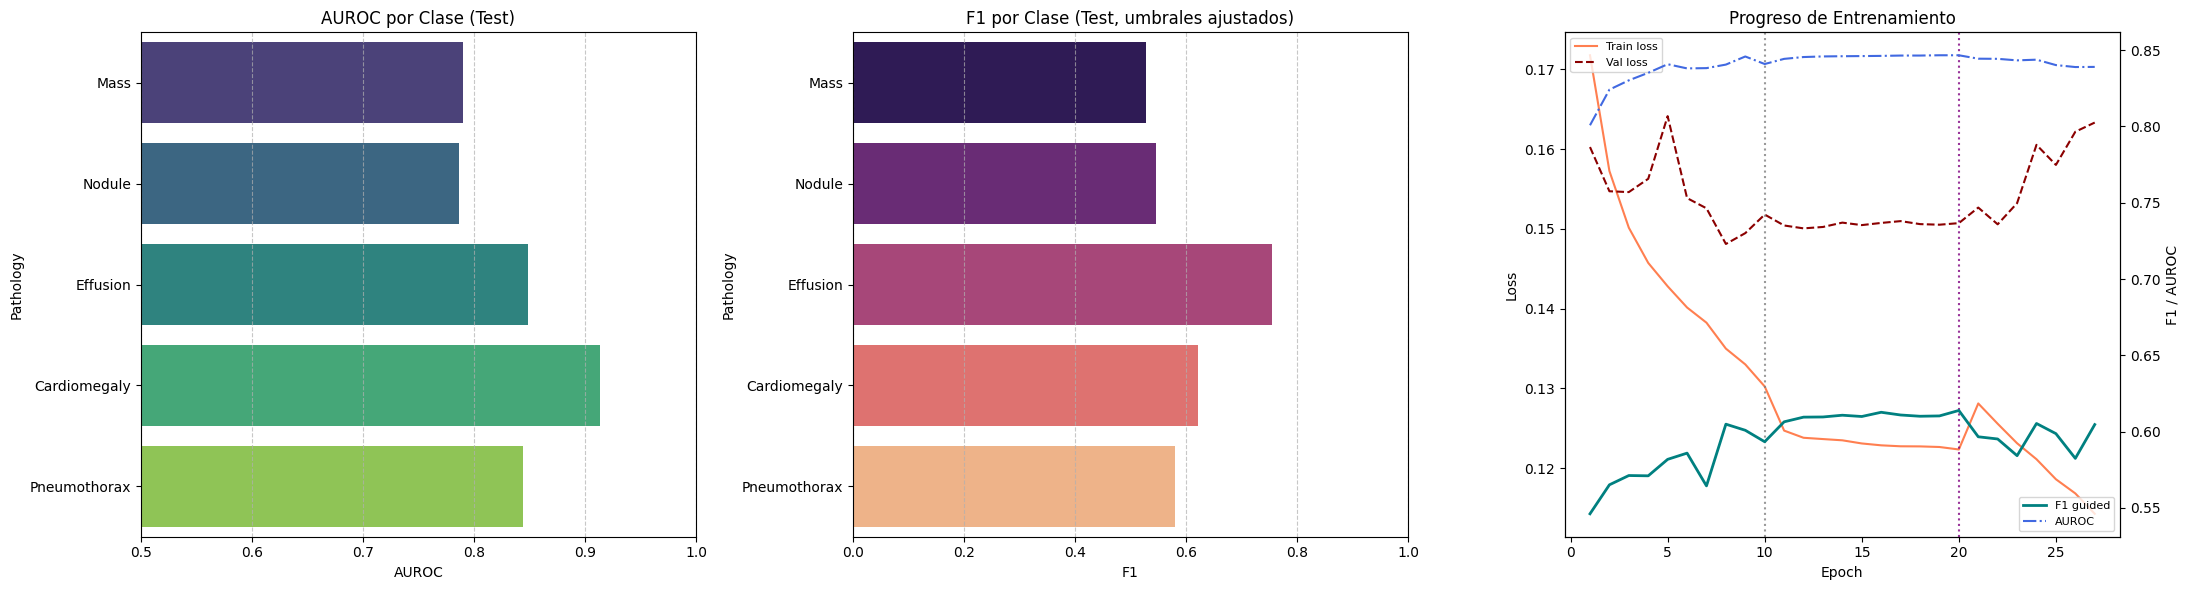


REPORTE (umbrales ajustados en val)
              precision    recall  f1-score   support

        Mass       0.45      0.64      0.53       879
      Nodule       0.45      0.71      0.55       967
    Effusion       0.64      0.91      0.76      2060
Cardiomegaly       0.56      0.70      0.62       447
Pneumothorax       0.49      0.71      0.58       751

   micro avg       0.54      0.78      0.64      5104
   macro avg       0.52      0.74      0.61      5104
weighted avg       0.54      0.78      0.64      5104
 samples avg       0.61      0.81      0.66      5104



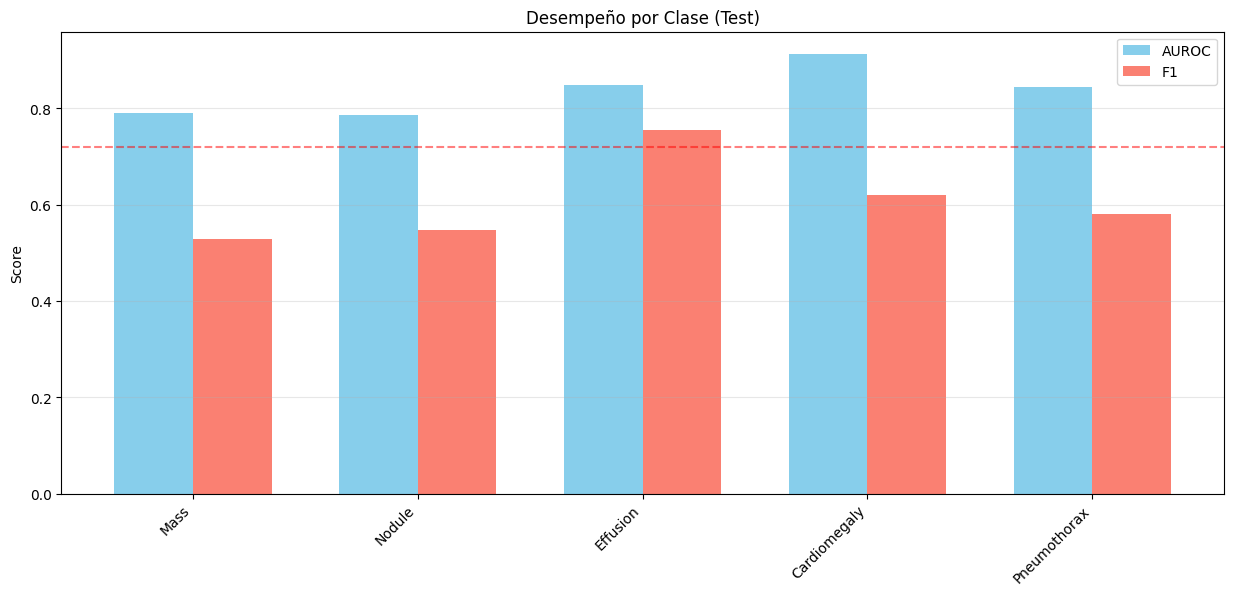

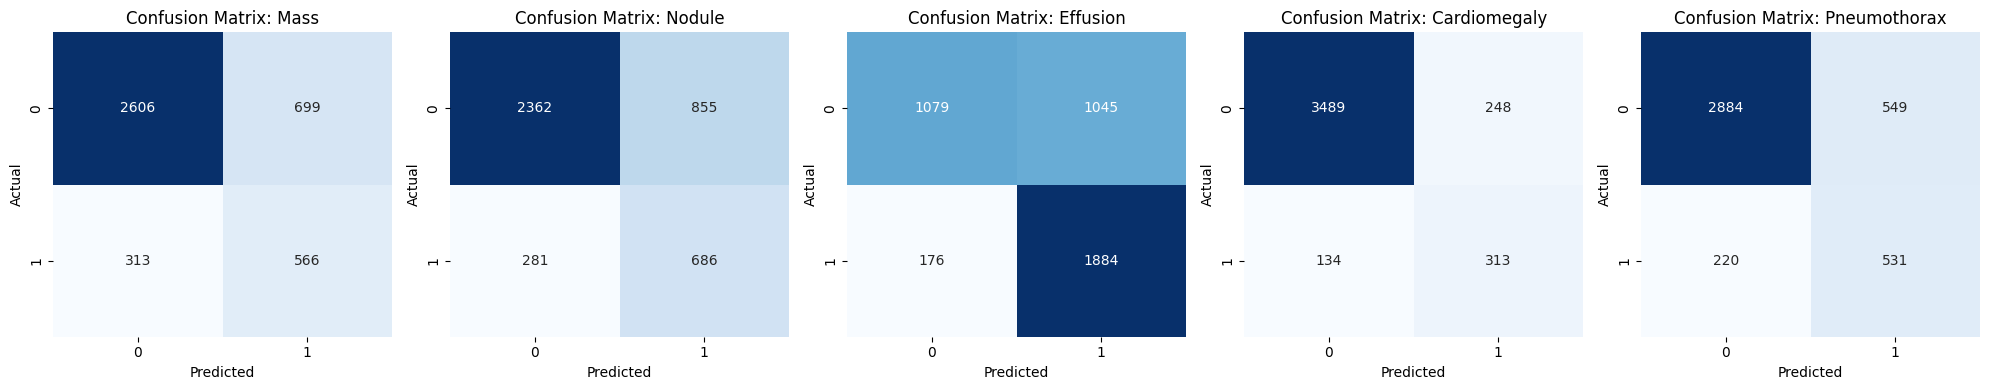

In [ ]:
# --- Cargar mejor checkpoint; umbrales en val; evaluar test ---


@torch.no_grad()
def collect_preds_labels(model, loader, device):
    model.eval()
    preds_l, labels_l = [], []
    for batch in loader:
        inputs = batch['image'].to(device)
        targets = batch['label'].to(device)
        with autocast():
            logits = model(inputs)
        preds_l.append(torch.sigmoid(logits).cpu().numpy())
        labels_l.append(targets.cpu().numpy())
    return np.vstack(preds_l), np.vstack(labels_l)


def tune_per_class_thresholds(val_preds, val_labels, classes, start=0.05, end=0.50, steps=46):
    grid = np.linspace(start, end, steps)
    thresholds = np.zeros(val_preds.shape[1])
    for c in range(val_preds.shape[1]):
        best_f1, best_t = -1.0, 0.5
        for t in grid:
            pb = (val_preds[:, c] >= t).astype(int)
            f = f1_score(val_labels[:, c], pb, average='binary', zero_division=0)
            if f > best_f1:
                best_f1, best_t = f, t
        thresholds[c] = best_t
    return thresholds


def metrics_from_probs(labels, preds, thresholds, classes=None, exclude=None):
    pred_bin = np.stack([preds[:, c] >= thresholds[c] for c in range(preds.shape[1])], axis=1).astype(int)
    result = {
        'f1_macro': f1_score(labels, pred_bin, average='macro', zero_division=0),
        'f1_micro': f1_score(labels, pred_bin, average='micro', zero_division=0),
        'auroc': roc_auc_score(labels, preds, average='macro', multi_class='ovr'),
        'pred_bin': pred_bin,
    }
    if exclude and classes:
        keep = [i for i, c in enumerate(classes) if c not in exclude]
        result['f1_macro_excl'] = f1_score(labels[:, keep], pred_bin[:, keep], average='macro', zero_division=0)
    return result


model.load_state_dict(torch.load(CONFIG['model_save_path'], map_location=CONFIG['device']))
model.to(CONFIG['device'])

val_preds, val_labels = collect_preds_labels(model, val_loader, CONFIG['device'])
test_preds, test_labels = collect_preds_labels(model, test_loader, CONFIG['device'])

thr_path = CONFIG['model_save_path'].replace('.pth', '_thresholds.npy')

if CONFIG.get('threshold_tuning', True):
    tuned = tune_per_class_thresholds(
        val_preds, val_labels, CONFIG['classes'],
        start=CONFIG['threshold_grid_start'],
        end=CONFIG['threshold_grid_end'],
        steps=CONFIG['threshold_grid_steps'],
    )
    np.save(thr_path, tuned)
    print('Umbrales por clase (val) guardados en:', thr_path)
    for i, cls in enumerate(CONFIG['classes']):
        print(f"  {cls:20}: t={tuned[i]:.3f}")
else:
    tuned = np.ones(len(CONFIG['classes'])) * 0.5

excl = CONFIG.get('exclude_from_macro', [])
tm_fix = metrics_from_probs(test_labels, test_preds, np.ones(len(CONFIG['classes'])) * 0.5,
                            CONFIG['classes'], excl)
tm_tuned = metrics_from_probs(test_labels, test_preds, tuned, CONFIG['classes'], excl)

print('\n' + '=' * 70)
print('RESULTADOS TEST (mejor checkpoint):')
print('=' * 70)
print(f"  Umbral fijo 0.5:")
print(f"    F1-Macro (14 cl): {tm_fix['f1_macro']:.4f} | F1-Micro: {tm_fix['f1_micro']:.4f} | AUROC: {tm_fix['auroc']:.4f}")
if 'f1_macro_excl' in tm_fix:
    print(f"    F1-Macro (excl {excl}): {tm_fix['f1_macro_excl']:.4f}")
print(f"  Umbrales ajustados (val):")
print(f"    F1-Macro (14 cl): {tm_tuned['f1_macro']:.4f} | F1-Micro: {tm_tuned['f1_micro']:.4f} | AUROC: {tm_tuned['auroc']:.4f}")
if 'f1_macro_excl' in tm_tuned:
    print(f"    F1-Macro (excl {excl}): {tm_tuned['f1_macro_excl']:.4f}")

print(f"\n{'Clase':20} | {'AUROC':>6} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | {'Nota'}")
print('-' * 75)
results_data = []
for i, cls in enumerate(CONFIG['classes']):
    c_auc = roc_auc_score(test_labels[:, i], test_preds[:, i])
    p, r, f, _ = precision_recall_fscore_support(
        test_labels[:, i], tm_tuned['pred_bin'][:, i],
        average='binary', zero_division=0,
    )
    nota = ' *** excl de macro guía' if cls in excl else ''
    results_data.append([cls, c_auc, p, r, f])
    print(f"{cls:20} | {c_auc:.4f} | {p:.4f} | {r:.4f} | {f:.4f} |{nota}")

res_df = pd.DataFrame(results_data, columns=['Pathology', 'AUROC', 'Precision', 'Recall', 'F1'])
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=res_df, x='AUROC', y='Pathology', palette='viridis', ax=axes[0])
axes[0].set_title('AUROC por Clase (Test)')
axes[0].set_xlim(0.5, 1.0)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

sns.barplot(data=res_df, x='F1', y='Pathology', palette='magma', ax=axes[1])
axes[1].set_title('F1 por Clase (Test, umbrales ajustados)')
axes[1].set_xlim(0.0, 1.0)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

epochs_range = range(1, len(history['train_loss']) + 1)
axes[2].plot(epochs_range, history['train_loss'], label='Train loss', color='coral')
axes[2].plot(epochs_range, history['val_loss'], label='Val loss', color='darkred', linestyle='--')
ax2 = axes[2].twinx()
if 'val_f1_macro_guided' in history:
    ax2.plot(epochs_range, history['val_f1_macro_guided'], label='F1 guided', color='teal', linewidth=2)
ax2.plot(epochs_range, history['val_auroc'], label='AUROC', color='royalblue', linestyle='-.')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
ax2.set_ylabel('F1 / AUROC')
axes[2].set_title('Progreso de Entrenamiento')
axes[2].legend(loc='upper left', fontsize=8)
ax2.legend(loc='lower right', fontsize=8)
eb = CONFIG['epochs_backbone']
eh = CONFIG['epochs_head']
if eb > 0:
    axes[2].axvline(x=eb, color='gray', linestyle=':', alpha=0.8)
if eh > 0:
    axes[2].axvline(x=eb + eh, color='purple', linestyle=':', alpha=0.8)

plt.tight_layout()
plt.show()


def plot_class_performance(labels, preds, pred_bin, classes):
    print("\n" + "=" * 60)
    print("REPORTE (umbrales ajustados en val)")
    print("=" * 60)
    print(classification_report(labels, pred_bin, target_names=classes, zero_division=0))

    plt.figure(figsize=(15, 6))
    aucs = [roc_auc_score(labels[:, i], preds[:, i]) for i in range(len(classes))]
    f1s = f1_score(labels, pred_bin, average=None, zero_division=0)
    x = np.arange(len(classes))
    width = 0.35
    plt.bar(x - width / 2, aucs, width, label='AUROC', color='skyblue')
    plt.bar(x + width / 2, f1s, width, label='F1', color='salmon')
    plt.axhline(0.72, color='red', linestyle='--', alpha=0.5)
    plt.title('Desempeño por Clase (Test)')
    plt.xticks(x, classes, rotation=45, ha='right')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_class_performance(test_labels, test_preds, tm_tuned['pred_bin'], CONFIG['classes'])


from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

mcm = multilabel_confusion_matrix(test_labels, tm_tuned['pred_bin'])
n_classes = len(CONFIG['classes'])
cols = min(5, n_classes)
rows = (n_classes + cols - 1) // cols

fig_cm, axes_cm = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
if n_classes == 1:
    axes_cm = [axes_cm]
else:
    axes_cm = axes_cm.flatten()

for i, cls in enumerate(CONFIG['classes']):
    ax = axes_cm[i]
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix: {cls}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for j in range(i + 1, len(axes_cm)):
    axes_cm[j].axis('off')

plt.tight_layout()
plt.show()


---

## 12. Visualización GradCAM *(opcional)*

Visualización de las regiones de activación del modelo para una clase determinada, mediante la última etapa del backbone MaxViT-Tiny.

> [!TIP]
> GradCAM permite interpretar clínicamente qué regiones de la radiografía estimulan la predicción de cada patología, contribuyendo a la **explicabilidad del sistema**.

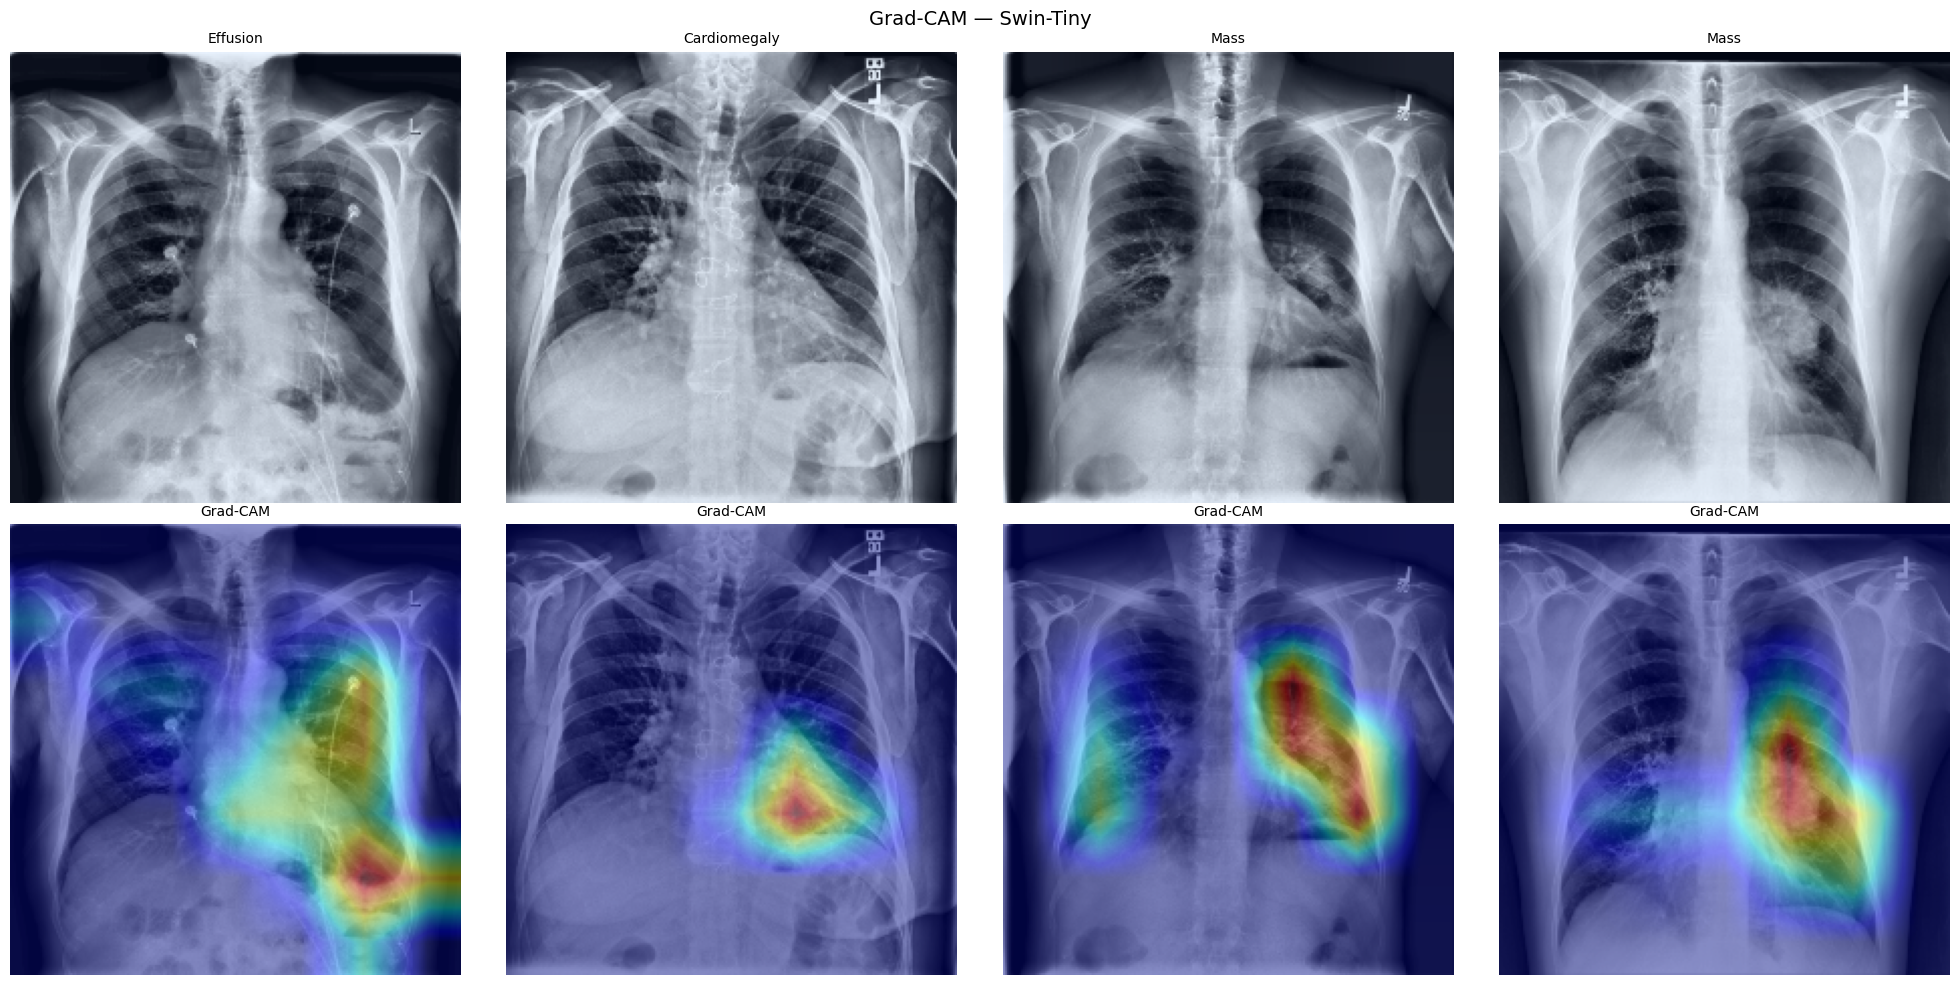

In [ ]:
def grad_cam(model, image_tensor, target_class_idx, device):
    """Grad-CAM sobre la última etapa del MaxViT-Tiny (timm)."""
    model.eval()
    img = image_tensor.unsqueeze(0).to(device)
    activations, gradients = {}, {}

    target_layer = model.model.layers[-1].blocks[-1]

    def fwd_hook(m, inp, out):
        activations['value'] = out.detach()

    def bwd_hook(m, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    h_fwd = target_layer.register_forward_hook(fwd_hook)
    h_bwd = target_layer.register_full_backward_hook(bwd_hook)

    logits = model(img)
    model.zero_grad()
    logits[0, target_class_idx].backward()

    h_fwd.remove()
    h_bwd.remove()

    grads = gradients['value']
    acts = activations['value']
    weights = grads.mean(dim=(1, 2), keepdim=True)
    cam = F.relu((weights * acts).sum(dim=3, keepdim=True))
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = cv2.resize(cam, (CONFIG['img_size'], CONFIG['img_size']))
    return cam


# --- Visualizar Grad-CAM sobre 4 muestras de test ---
model.load_state_dict(torch.load(CONFIG['model_save_path'], map_location=CONFIG['device']))

sample_batch = next(iter(test_loader))
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i in range(min(4, sample_batch['image'].size(0))):
    img_t = sample_batch['image'][i]
    label = sample_batch['label'][i]
    target_cls = int(label.argmax())

    cam = grad_cam(model, img_t, target_cls, CONFIG['device'])

    img_np = img_t.permute(1, 2, 0).detach().cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(CONFIG['classes'][target_cls], fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(img_np)
    axes[1, i].imshow(cam, cmap='jet', alpha=0.4)
    axes[1, i].set_title('Grad-CAM', fontsize=10)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM — Swin-Tiny', fontsize=14)
plt.tight_layout()
plt.show()
